In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# สร้างข้อมูลตัวอย่าง
X, y = make_regression(n_samples=1000, n_features=1, noise=10, random_state=42)

# แบ่ง train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# สร้างโมเดล
lr_model = LinearRegression()

# train
lr_model.fit(X_train, y_train)

# ทำนาย
pred_train = lr_model.predict(X_train)
pred_test = lr_model.predict(X_test)

# ประเมินผล
print("MAE Train:", mean_absolute_error(y_train, pred_train))
print("MAE Test:", mean_absolute_error(y_test, pred_test))

# ค่าพารามิเตอร์
print("Coefficient:", lr_model.coef_)
print("Intercept:", lr_model.intercept_)


MAE Train: 7.83581088020999
MAE Test: 8.17151494788362
Coefficient: [16.71653147]
Intercept: -0.09250102697112714


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# โหลดข้อมูล
housing = fetch_california_housing()
X = housing.data
y = housing.target

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# สร้างโมเดล
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# train
rf_reg.fit(X_train, y_train)

# predict
y_pred_train = rf_reg.predict(X_train)
y_pred_test = rf_reg.predict(X_test)

# ประเมินผล
print("MAE Train:", mean_absolute_error(y_train, y_pred_train))
print("MAE Test:", mean_absolute_error(y_test, y_pred_test))


MAE Train: 0.12205671543120195
MAE Test: 0.32754256845930246


Random Forest Regressor Results:
Train R² Score: 0.8692
Test R² Score: 0.7737
Test RMSE: 0.5446
Test MAE: 0.3666


C:\Users\konkh\AppData\Local\Temp\ipykernel_18332\3744902977.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='coolwarm')


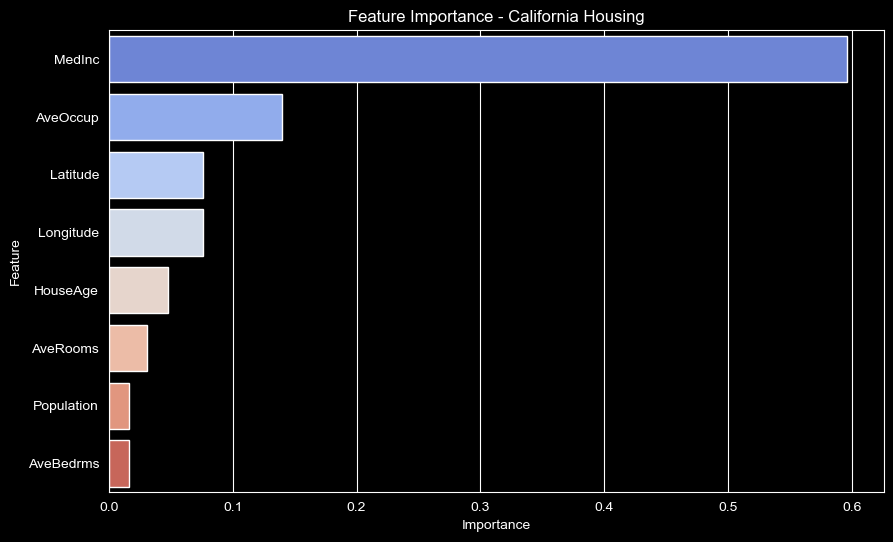

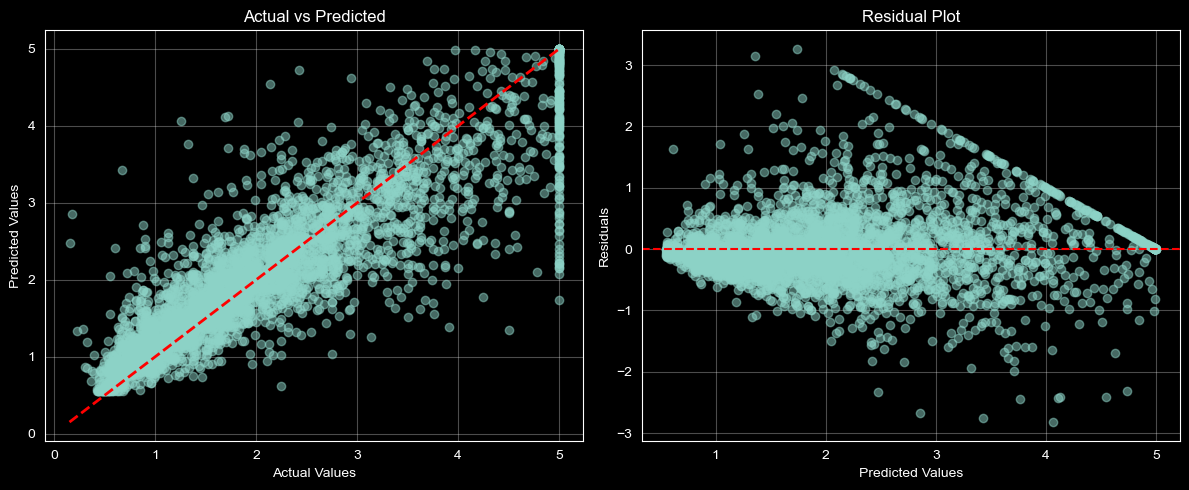

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(X_train, y_train)

y_pred_train = rf_regressor.predict(X_train)
y_pred_test = rf_regressor.predict(X_test)

print("Random Forest Regressor Results:")
print(f"Train R² Score: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R² Score: {r2_score(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")

importance = rf_regressor.feature_importances_

feature_importance = pd.DataFrame({
    'feature': housing.feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='coolwarm')
plt.title('Feature Importance - California Housing')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.grid(True, alpha=0.3)

residuals = y_test - y_pred_test

plt.subplot(1, 2, 2)
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
